# Loi de Malus : sans le polariseur

In [44]:
import glob, os
import ast
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import Normalize
from matplotlib.cm import ScalarMappable
from astropy.io import fits
from scipy.optimize import curve_fit
from matplotlib.ticker import MultipleLocator
from astropy.stats import sigma_clipped_stats
#import data_manage_lib as dml

%matplotlib widget

In [83]:
def get_colors(n_steps, cmap_name='Blues', vmin=0, vmax=None):
    if vmax is None:
        vmax = n_steps - 1
    norm = Normalize(vmin=vmin, vmax=vmax)
    cmap = plt.get_cmap(cmap_name)
    return [cmap(norm(i)) for i in range(n_steps)], norm, cmap

def has_key(hdul, key='THETA_R'):
    """Retourne True si THETA_R existe dans le header"""
    return key in hdul[0].header

def get_chi2(data, model, error):
    chi2 = np.sum((data - model)**2 / error**2)
    return chi2

def fold_angles_180(angles):
    """Fold angles to [-90, 90] range using 180° symmetry.
    Transforms angles so that 100° → 80°, 110° → 70°, etc.
    """
    angles = np.asarray(angles)
    # Fold angles > 90
    folded = np.where(angles > 90, 180 - angles, angles)
    # Fold angles < -90
    folded = np.where(folded < -90, -180 - folded, folded)
    return folded.tolist() if isinstance(angles, list) else folded

In [3]:
path_save = '/home/lmousset/Projets_Recherche/COSMOCal/Tests_IAS_2026/Data/'
#path_save = "C:\\Users\\Administrator\\Documents\\Scripts_Commande_VNA\\CosmoCal_data\\"



# Premier essai mardi 17/02 : quelques points mesurés à vue

In [ ]:
S21 = np.array([-38, -38, -38.7, -39, -39.5, -40, -41.2, -43, -46.5, -52.3, -64.8, -52.4, -47.3, -47, -44.5, -41.2, -41.7, -39])
nmeas = np.size(S21)
angle = np.arange(nmeas)*10

plt.figure()
plt.plot(angle, 10**(S21/10), 'o')

### Première acquisiton mercredi 18/02 : un fichier pour chaque thetaR

In [ ]:
allthetaR = []
allmag = []

path_save2 = path_save + 'Malus_manual/'
os.chdir(path_save2)

i = 0
for file in glob.glob("*thetaR*.fits"):
    print(i)
    print(file)
    hdul = fits.open(path_save2 + file)
    header = hdul[0].header
    thetaR = header['THETA_R']
    allthetaR.append(thetaR)
    mag = hdul[0].data  # Access magnitude
    print(mag.shape)
    allmag.append(mag)
    i+=1

allthetaR = np.array(allthetaR)
allmag = np.array(allmag)
print(allmag.shape)

In [ ]:
ff = 10
colors, norm, cmap = get_colors(ff, cmap_name='viridis', vmin=0, vmax=ff-1)
trace = 0 # S21
plt.figure()
for f in range(ff):
    plt.plot(allthetaR[1:-2], 10**(allmag[1:-2, trace, f]/10), 'o', color=colors[f])

# Nouvelle optimisation : 1 seul fichier

On stop le script pour tourner thetaR 

In [32]:
# Get data from one file
hdul = fits.open(path_save + "Malus_20260220_103113.fits")
header = hdul[0].header
hdul.info()  # View structure
mag = hdul[0].data  # Access magnitude
mag_lin = 10**(mag/10)

# Pour les premiers runs, THETA_R n'était pas sauvegardé
if has_key(hdul, key='THETA_R'):
    thetaR = ast.literal_eval(header['THETA_R'])
else:
    print("THETA_R not found in header, using default values.")
    thetaR = [0, 10, 20, 30, 40, 50, 60, 70, 80, 90, 100, 110, 120, 
             0, -10, -20, -30, -40, -50, -60, -70, -80, -90, -100, -110, -120] # in degree

print(f"thetaR: {thetaR}")

header

Filename: /home/lmousset/Projets_Recherche/COSMOCal/Tests_IAS_2026/Data/Malus_20260220_103113.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  MAGNITUDE     1 PrimaryHDU      16   (60, 4, 30)   float64   
  1  PHASE         1 ImageHDU        10   (60, 4, 30)   float64   
thetaR: [0, 10, 20, 30, 40, 50, 60, 70, 80, 90, 100, 110, 120, 130, 140, 0, -10, -20, -30, -40, -50, -60, -70, -80, -90, -100, -110, -120, -130, -140]


SIMPLE  =                    T / conforms to FITS standard                      
BITPIX  =                  -64 / array data type                                
NAXIS   =                    3 / number of array dimensions                     
NAXIS1  =                   60                                                  
NAXIS2  =                    4                                                  
NAXIS3  =                   30                                                  
EXTEND  =                    T                                                  
EXTNAME = 'MAGNITUDE'                                                           
DATATYPE= 'Magnitude in dB'                                                     
THETA_R = '[0, 10, 20, 30, 40, 50, 60, 70, 80, 90, 100, 110, 120, 130, 140, &'  
CONTINUE  '0, -10, -20, -30, -40, -50, -60, -70, -80, -90, -100, -110, -120, &' 
CONTINUE  '-130, -140]'                                                         
START_FR=       110000000000

In [33]:
# Get data from a second file
hdul2 = fits.open(path_save + "Malus_20260220_105809.fits")
header = hdul2[0].header
hdul2.info()  # View structure
mag2 = hdul2[0].data  # Access magnitude
mag2_lin = 10**(mag2/10)

if has_key(hdul2, key='THETA_R'):
    thetaR2 = ast.literal_eval(header['THETA_R'])
else:
    print("THETA_R not found in header, using default values.")
    thetaR2 = [-30, 0, 30] # in degree

print(f"thetaR2: {thetaR2}")

header

Filename: /home/lmousset/Projets_Recherche/COSMOCal/Tests_IAS_2026/Data/Malus_20260220_105809.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  MAGNITUDE     1 PrimaryHDU      16   (60, 4, 5)   float64   
  1  PHASE         1 ImageHDU        10   (60, 4, 5)   float64   
thetaR2: [-60, -30, 0, 30, 60]


SIMPLE  =                    T / conforms to FITS standard                      
BITPIX  =                  -64 / array data type                                
NAXIS   =                    3 / number of array dimensions                     
NAXIS1  =                   60                                                  
NAXIS2  =                    4                                                  
NAXIS3  =                    5                                                  
EXTEND  =                    T                                                  
EXTNAME = 'MAGNITUDE'                                                           
DATATYPE= 'Magnitude in dB'                                                     
THETA_R = '[-60, -30, 0, 30, 60]'                                               
START_FR=       110000000000.0                                                  
STOP_FRQ=       170000000000.0                                                  
POINTS  =                   

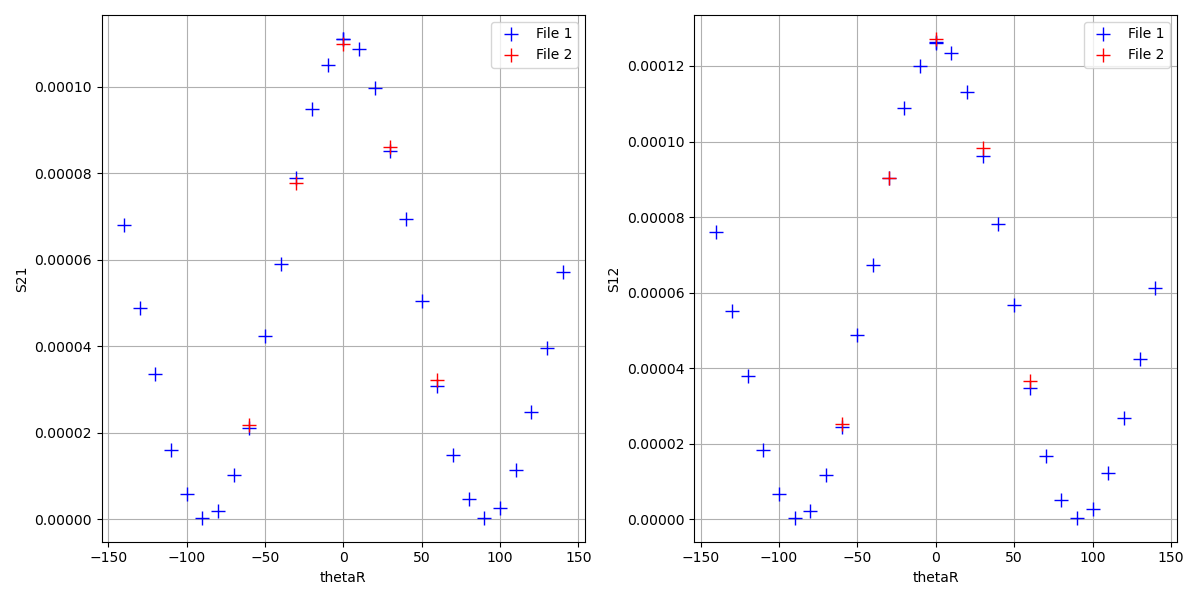

In [6]:
# Plot the mean S21 and S12 for both files
fig, axs = plt.subplots(1, 2, figsize=(12, 6))
axs = axs.ravel()

# S21
axs[0].plot(thetaR, np.mean(mag_lin[:, 0, :], axis=1), 'b+', ms=10, label='File 1')
axs[0].plot(thetaR2, np.mean(mag2_lin[:, 0, :], axis=1), 'r+', ms=10, label='File 2')
axs[0].set_xlabel('thetaR')
axs[0].set_ylabel('S21')
axs[0].legend()

#S12
axs[1].plot(thetaR, np.mean(mag_lin[:, 1, :], axis=1), 'b+', ms=10, label='File 1')
axs[1].plot(thetaR2, np.mean(mag2_lin[:, 1, :], axis=1), 'r+', ms=10, label='File 2')
axs[1].set_xlabel('thetaR')
axs[1].set_ylabel('S12')
axs[1].legend()

axs[0].grid()
axs[1].grid()

fig.tight_layout()
#fig.savefig('../Plots/Malus_20260220_103113et105809_sansPlatine.png', dpi=300)

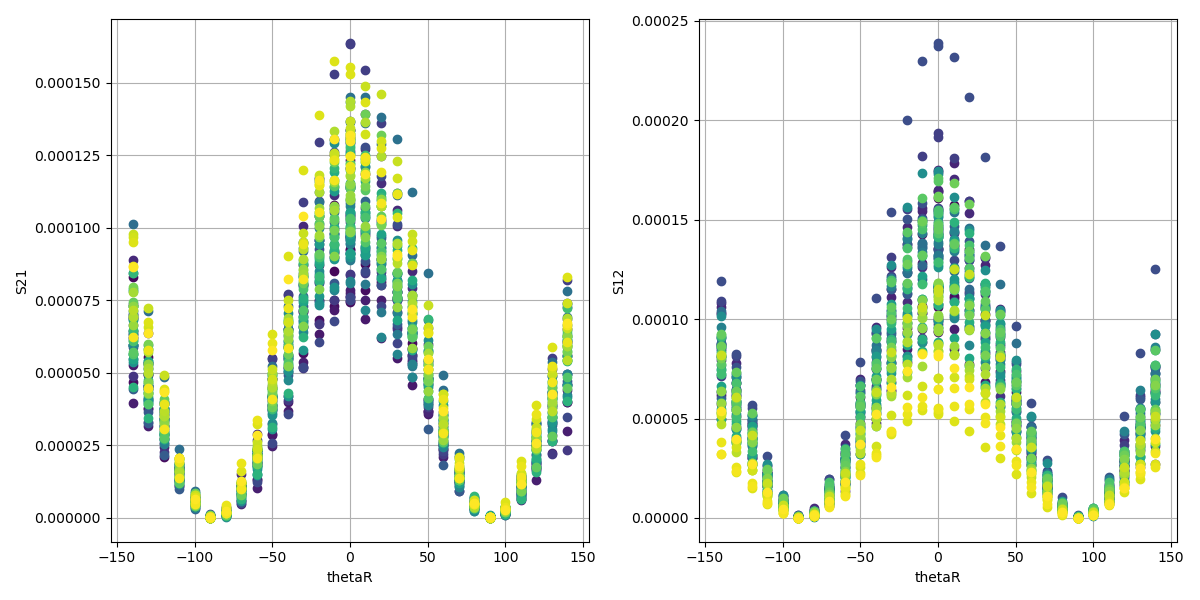

In [7]:
# Plot each frequency separately
freqs = [0, 10, 20, 30, 40]
freqs = np.arange(60)
ff = len(freqs)
colors, norm, cmap = get_colors(ff, cmap_name='viridis', vmin=0, vmax=ff-1)

fig, axs = plt.subplots(1, 2, figsize=(12, 6))
axs = axs.ravel()
for f, freq in enumerate(freqs):
    axs[0].plot(thetaR, mag_lin[:, 0, freq], 'o', color=colors[f])
    #axs[0].plot(thetaR2, mag2_lin[:, 0, freq], 'r+', ms=10)
axs[0].set_xlabel('thetaR')
axs[0].set_ylabel('S21')
#axs[0].set_yscale('log')

for f, freq in enumerate(freqs):
    axs[1].plot(thetaR, mag_lin[:, 1, freq], 'o', color=colors[f])
    #axs[1].plot(thetaR2, mag2_lin[:, 1, freq], 'r+', ms=10)
axs[1].set_xlabel('thetaR')
axs[1].set_ylabel('S12')
#axs[1].set_yscale('log')

axs[0].grid()
axs[1].grid()

fig.tight_layout()
#fig.savefig('../Plots/Malus_20260220_103113_all_freqs.png', dpi=300)

In [8]:

for ang in [-60, -30, 0, 30, 60]:
    idx2 = np.where(np.array(thetaR2) == ang)[0]

    if ang != 0:
        idx = np.where(np.array(thetaR) == ang)[0]
    else:
        idx = np.where(np.array(thetaR) == ang)[0][0]
    #print(f"Index of {ang} in thetaR: {idx}")
    #print(f"Index of {ang} in thetaR2: {idx2}")

    diff = np.zeros(60)
    for f in range(60):
        #diff[f] = (10**(mag[idx, 0, f]/10) - 10**(mag2[idx2, 0, f]/10))
        diff[f] = (mag[idx, 0, f] - mag2[idx2, 0, f])
    #print(f"Frequency {f}: Difference = {diff}")

    print(f"Angle {ang}°: Mean difference = {np.mean(diff):.2e}, Std difference = {np.std(diff):.2e}")


Angle -60°: Mean difference = -1.42e-01, Std difference = 8.36e-02
Angle -30°: Mean difference = 5.96e-02, Std difference = 6.86e-02
Angle 0°: Mean difference = 4.60e-02, Std difference = 7.43e-02
Angle 30°: Mean difference = -4.86e-02, Std difference = 9.98e-02
Angle 60°: Mean difference = -1.75e-01, Std difference = 1.14e-01


/tmp/ipykernel_180266/322527434.py:14: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  diff[f] = (mag[idx, 0, f] - mag2[idx2, 0, f])


In [9]:
#plt.figure()
#plt.plot(diff, 'o')
# plt.axhline(np.mean(diff), linestyle='--', label=f'Mean = {np.mean(diff):.2e}')
# plt.axhline(np.mean(diff)+np.std(diff), linestyle='--')
# plt.axhline(np.mean(diff)-np.std(diff), linestyle='--')
# plt.xlabel('Frequency index')
# plt.ylabel('Difference')
# plt.title(f'Angle = {ang}° - Mean = {np.mean(diff):.2e} - Std = {np.std(diff):.2e}')
# plt.legend()

# Estimation des erreurs

On a fait 5 scans identiques avec alpha = [-90, -90, -45, 0, 45, 90, 90]

In [10]:
allthetaR = []
allmag = []

os.chdir(path_save)

i = 0
for file in glob.glob("Malus_20260220_14*.fits"):
    #if i>0:
    print(i)
    print(file)
    hdul = fits.open(path_save + file)
    header = hdul[0].header
    thetaR = header['THETA_R']
    print(f"thetaR: {thetaR}")
    allthetaR.append(ast.literal_eval(thetaR))
    mag = hdul[0].data  # Access magnitude
    print(mag.shape)
    allmag.append(mag)
    i+=1

allmag = np.array(allmag)
allthetaR = np.array(allthetaR)
print(allmag.shape)

allmag_lin = 10**(allmag/10)

nscans, nthetaR, nS, nfreqs = allmag_lin.shape

0
Malus_20260220_143933.fits
thetaR: [-90, -90, -45, 0, 45, 90, 90]
(7, 4, 60)
1
Malus_20260220_143358.fits
thetaR: [-90, -90, -45, 0, 45, 90, 90]
(7, 4, 60)
2
Malus_20260220_145115.fits
thetaR: [-90, -90, -45, 0, 45, 90, 90]
(7, 4, 60)
3
Malus_20260220_144453.fits
thetaR: [-90, -90, -45, 0, 45, 90, 90]
(7, 4, 60)
4
Malus_20260220_145628.fits
thetaR: [-90, -90, -45, 0, 45, 90, 90]
(7, 4, 60)
(5, 7, 4, 60)


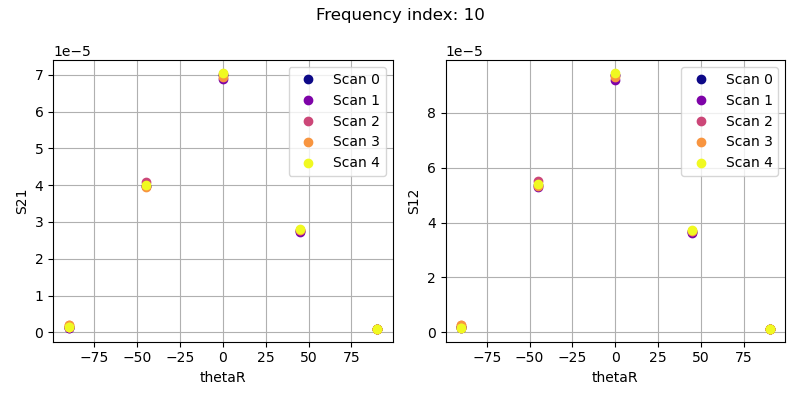

In [11]:
# Plot each frequency separately (avec les 5 scans)
freqs = [10] # indice de la frequence
colors, norm, cmap = get_colors(nscans, cmap_name='plasma', vmin=0, vmax=nscans-1)

fig, axs = plt.subplots(1, 2, figsize=(8, 4))
axs = axs.ravel()

## S21
for m in range(nscans):
    for i, f in enumerate(freqs):
        axs[0].plot(allthetaR[m], allmag_lin[m, :, 0, f], 'o', color=colors[m], label=f'Scan {m}')
axs[0].set_xlabel('thetaR')
axs[0].set_ylabel('S21')
#axs[0].set_yscale('log')
axs[0].grid()
axs[0].legend()

## S12
for m in range(nscans):
    for i, f in enumerate(freqs):
        axs[1].plot(allthetaR[m], allmag_lin[m, :, 1, f], 'o', color=colors[m], label=f'Scan {m}')
axs[1].set_xlabel('thetaR')
axs[1].set_ylabel('S12')
#axs[1].set_yscale('log')
axs[1].grid()
axs[1].legend()

fig.suptitle(f'Frequency index: {freqs[0]}')
fig.tight_layout()

In [12]:
# Mean and STD sur les 5 scans
mean_over_scans = np.mean(allmag_lin, axis=0)
std_over_scans = np.std(allmag_lin, axis=0) # [nangle, nS, nfreq]

print(mean_over_scans.shape)

(7, 4, 60)


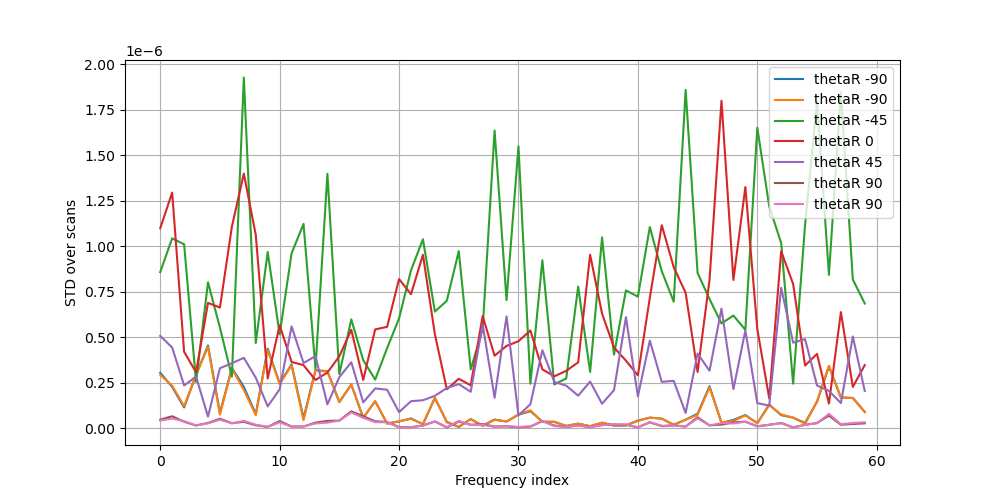

In [40]:
# STD sur les 5 scans en fonction de thetaR et de la frequence
# On voit que le STD est plus grand pour les angles 0 et +-45 que pour les angles +-90°.
# Pour thetaR = 90, les cornets sont croisés => pas de signal. Le STD a l'air de suivre l'amplitude du signal.
t = 0 # S21 ou S12

fig, axs = plt.subplots(1, 1, figsize=(10, 5))
for a in range(nthetaR): # pour chaque angle
    axs.plot(std_over_scans[a, t, :], label=f'thetaR {allthetaR[0][a]}')
axs.set_xlabel('Frequency index')
axs.set_ylabel('STD over scans')
axs.legend()
axs.grid()

#fig.savefig(f"../Plots/Malus_STD_over_scans.png", dpi=300)

(7, 4)


Text(0, 0.5, 'STD over scans and freq')

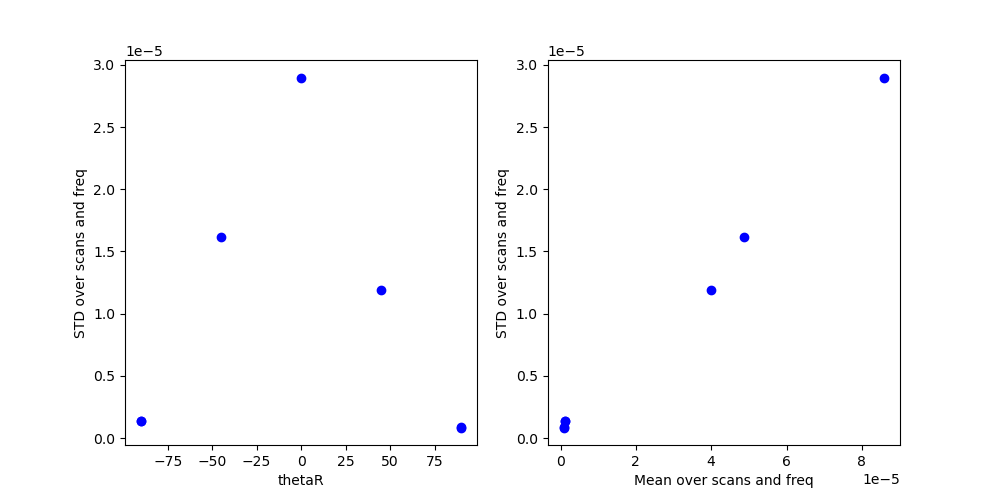

In [48]:
mean_over_scansfreq = np.mean(allmag_lin, axis=(0, 3))
std_over_scansfreq = np.std(allmag_lin, axis=(0, 3)) # [nangle, nS]

print(mean_over_scansfreq.shape)

t = 0
fig, axs = plt.subplots(1, 2, figsize=(10, 5))
axs[0].plot(allthetaR[0], std_over_scansfreq[:, t], 'bo')
axs[0].set_xlabel('thetaR')
axs[0].set_ylabel('STD over scans and freq')

# STD en fonction de l'amplitude moyenne du signal
axs[1].plot(mean_over_scansfreq[:, t], std_over_scansfreq[:, t], 'bo')
axs[1].set_xlabel('Mean over scans and freq')
axs[1].set_ylabel('STD over scans and freq')

Fitted parameter a: 3.31e-01


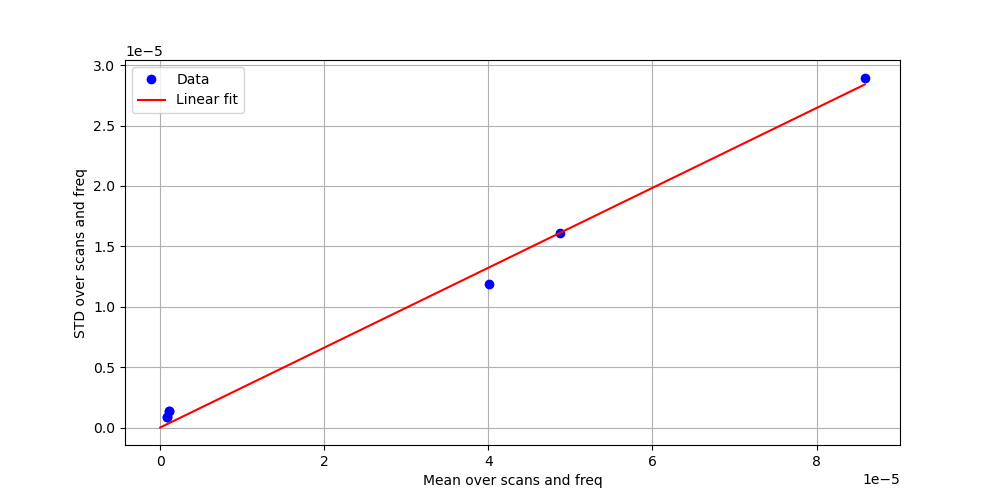

In [46]:
# On voit que le STD a l'air d'être proportionnel à l'amplitude du signal, ce qui suggère que le bruit est multiplicatif 
# Faisons un ajustement linéaire du STD en fonction de la moyenne pour vérifier cela
def linear_model(x, a):
    return a * x
popt, pcov = curve_fit(linear_model, mean_over_scansfreq[:, t], std_over_scansfreq[:, t])
a_fit = popt[0]
print(f"Fitted parameter a: {a_fit:.2e}")

fig, axs = plt.subplots(1, 1, figsize=(10, 5))
axs.plot(mean_over_scansfreq[:, t], std_over_scansfreq[:, t], 'bo', label='Data')
x_fit = np.linspace(0, np.max(mean_over_scansfreq[:, t]), 100)
axs.plot(x_fit, linear_model(x_fit, *popt), 'r-', label='Linear fit')
axs.set_xlabel('Mean over scans and freq')
axs.set_ylabel('STD over scans and freq')
axs.legend()
axs.grid()
#chi2 = get_chi2(std_over_scansfreq[:, t], linear_model(mean_over_scansfreq[:, t], *popt), std_over_scansfreq[:, t])
#print("Chi2 :", chi2)

#chi2_red = chi2 / (len(thetaR) - len(popt))
#print("Chi2 réduit :", chi2_red)

In [51]:
allthetaR[0][1:-2]

array([-90, -45,   0,  45])

[1.36481736e-06 1.96172828e-06 2.55863919e-06 3.15555011e-06
 3.75246103e-06 4.34937194e-06 4.94628286e-06 5.54319378e-06
 6.14010469e-06 6.73701561e-06 7.33392653e-06 7.93083744e-06
 8.52774836e-06 9.12465928e-06 9.72157019e-06 1.03184811e-05
 1.09153920e-05 1.15123029e-05 1.21092139e-05 1.27061248e-05
 1.33030357e-05 1.38999466e-05 1.44968575e-05 1.50937684e-05
 1.56906794e-05 1.62681296e-05 1.67871979e-05 1.73062662e-05
 1.78253345e-05 1.83444028e-05 1.88634710e-05 1.93825393e-05
 1.99016076e-05 2.04206759e-05 2.09397442e-05 2.14588125e-05
 2.19778808e-05 2.24969490e-05 2.30160173e-05 2.35350856e-05
 2.40541539e-05 2.45732222e-05 2.50922905e-05 2.56113588e-05
 2.61304270e-05 2.66494953e-05 2.71685636e-05 2.76876319e-05
 2.82067002e-05 2.87257685e-05 2.86403249e-05 2.79503695e-05
 2.72604140e-05 2.65704586e-05 2.58805032e-05 2.51905477e-05
 2.45005923e-05 2.38106369e-05 2.31206814e-05 2.24307260e-05
 2.17407705e-05 2.10508151e-05 2.03608597e-05 1.96709042e-05
 1.89809488e-05 1.829099

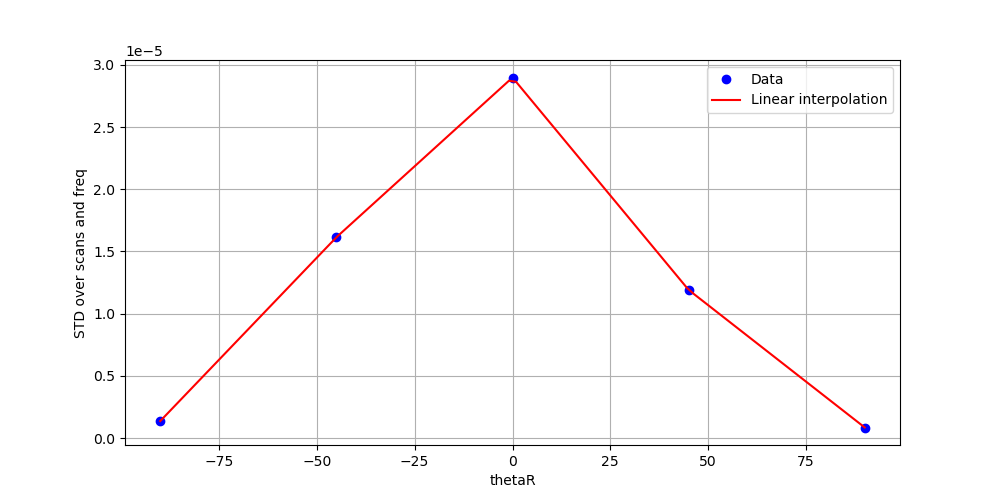

In [66]:
# On interpole le STD en fonction de thetaR pour avoir un modèle d'erreurs en fonction de thetaR
from scipy.interpolate import interp1d
interp_func = interp1d(allthetaR[0][1:-1], std_over_scansfreq[:, t][1:-1], kind='linear', fill_value='extrapolate')

thetaR_interp = np.linspace(np.min(allthetaR[0][1:-1]), np.max(allthetaR[0][1:-1]), 100)
std_interp = interp_func(thetaR_interp) 
print(std_interp)

fig, axs = plt.subplots(1, 1, figsize=(10, 5))
axs.plot(allthetaR[0][1:-1], std_over_scansfreq[:, t][1:-1], 'bo', label='Data')
axs.plot(thetaR_interp, std_interp, 'r-', label='Linear interpolation')
axs.set_xlabel('thetaR')
axs.set_ylabel('STD over scans and freq')
axs.legend()
axs.grid()

### Deux mesures successives sans rien changer

In [17]:
t = 0

m90a = allmag_lin[:,0,t,:]
m90b = allmag_lin[:,1,t,:]

p90a = allmag_lin[:,5,t,:]
p90b = allmag_lin[:,6,t,:]


diff_p90 = p90a - p90b
diff_m90 = m90a - m90b

print(diff_p90.shape)

mean_p90, median_p90, stddev_p90 = sigma_clipped_stats(diff_p90, sigma=2)
print(mean_p90, median_p90, stddev_p90)

mean_m90, median_m90, stddev_m90 = sigma_clipped_stats(diff_m90, sigma=2)
print(mean_m90, median_m90, stddev_m90)


(5, 60)
3.294866737973405e-10 2.3053853540336728e-10 3.892336930840925e-09
-9.050679260162076e-10 -5.644605451129438e-10 4.1543215031524865e-09


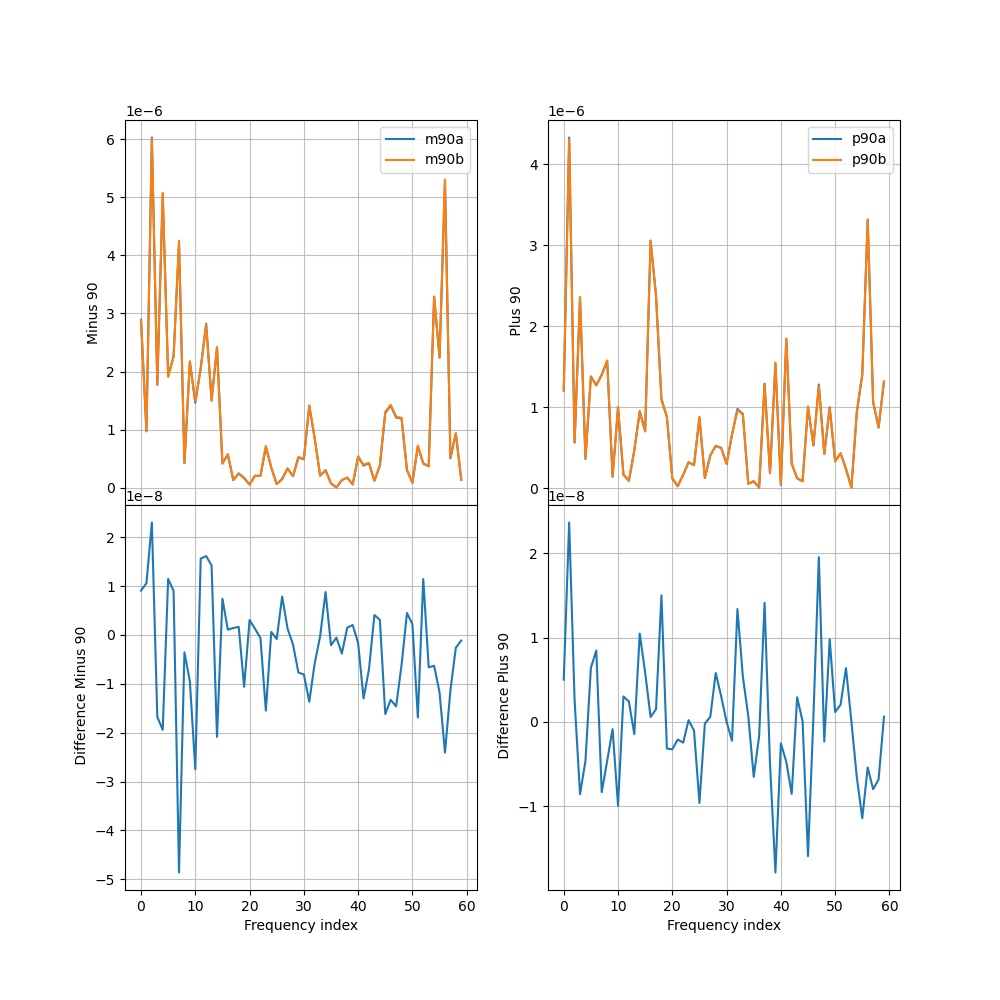

In [18]:
fig, axs = plt.subplots(2, 2, figsize=(10, 10), sharex='col')
axs = axs.ravel()

m = 2 # indice du scan

axs[0].plot(m90a[m, :], label='m90a')
axs[0].plot(m90b[m, :], label='m90b')
#axs[0].set_xlabel('Frequency index')
axs[0].set_ylabel('Minus 90')
axs[0].legend()
axs[0].xaxis.set_major_locator(MultipleLocator(10))
axs[0].grid(which='major', alpha=0.8)

axs[1].plot(p90a[m, :], label='p90a')
axs[1].plot(p90b[m, :], label='p90b')
#axs[1].set_xlabel('Frequency index')
axs[1].set_ylabel(' Plus 90')
axs[1].legend()
axs[1].xaxis.set_major_locator(MultipleLocator(10))
axs[1].grid(which='major', alpha=0.8)

axs[2].plot(diff_m90[m, :])
axs[2].set_xlabel('Frequency index')
axs[2].set_ylabel(' Difference Minus 90')
axs[2].xaxis.set_major_locator(MultipleLocator(10))
axs[2].grid(which='major', alpha=0.8)

axs[3].plot(diff_p90[m, :])
axs[3].set_xlabel('Frequency index')
axs[3].set_ylabel(' Difference Plus 90')
axs[3].xaxis.set_major_locator(MultipleLocator(10))
axs[3].grid(which='major', alpha=0.8)

fig.subplots_adjust(hspace=0)

# Ajustement

In [ ]:
# Get data from one file
hdul = fits.open(path_save + "Malus_20260220_103113.fits")
header = hdul[0].header
hdul.info()  # View structure
mag = hdul[0].data  # Access magnitude
mag_lin = 10**(mag/10)

if has_key(hdul, key='THETA_R'):
    thetaR = ast.literal_eval(header['THETA_R'])
else:
    print("THETA_R not found in header, using default values.")
    thetaR = [0, 10, 20, 30, 40, 50, 60, 70, 80, 90, 100, 110, 120, 
             0, -10, -20, -30, -40, -50, -60, -70, -80, -90, -100, -110, -120] # in degree

print(f"thetaR: {thetaR}")

header

In [21]:
# Model function for fitting
def cos2(theta_R, theta_E, A):
    return A * np.cos(np.radians(theta_E - theta_R))**2



### Ajustement de la moyenne

Fitting without error bars...
Paramètres optimisés : [2.41713628e+00 1.10082984e-04]
Erreurs sur les paramètres : [1.51836408e-01 3.83217338e-07]
Écart-type des résidus : 1.106641741745161e-06
Chi2 : 30.01909246495133
Chi2 réduit : 1.0721104451768333


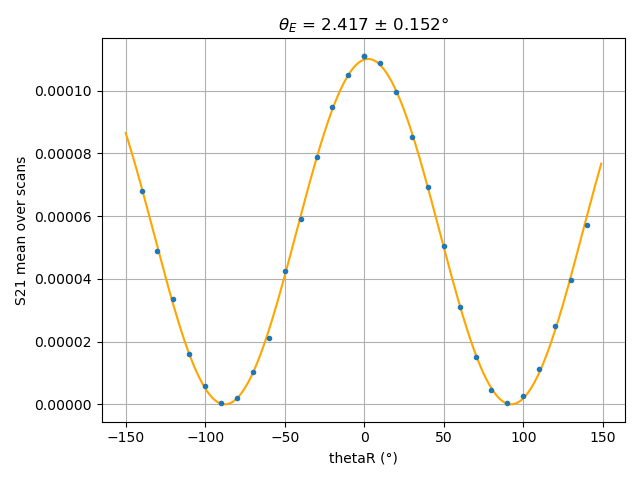

In [58]:
### Sans barres d'erreur
print("Fitting without error bars...")
t = 0 # trace index (S21 or S12)
tt = np.arange(-150, 150, 1)

signal = np.mean(mag_lin[:, 0, :], axis=1)


# Fit the data
popt, pcov = curve_fit(cos2, thetaR, signal)
error = np.sqrt(np.diag(pcov))

print("Paramètres optimisés :", popt)
print("Erreurs sur les paramètres :", error)

# Residus et chi2 pour vérifier que le chi2 reduit vaut 1
residuals = signal - cos2(thetaR, *popt)
# Le STD des résidus nous donne une estimation de l'erreur sur les données, que l'on peut utiliser pour calculer le chi2
std_res = np.std(residuals)
print("Écart-type des résidus :", std_res)
chi2 = get_chi2(signal, cos2(thetaR, *popt), std_res)
print("Chi2 :", chi2)
chi2_red = chi2 / (len(thetaR) - len(popt))
print("Chi2 réduit :", chi2_red)

fig = plt.figure()
plt.errorbar(thetaR, signal, yerr=None, marker='.', ls='None')
plt.plot(tt, cos2(tt, *popt), 'orange', label='Fit cos^2')
plt.xlabel("thetaR (°)")
plt.ylabel("S21 mean over scans")
plt.title(r'$\theta_E$ = {:.3f} ± {:.3f}°'.format(popt[0], error[0]))
plt.grid(10)

fig.tight_layout()
#fig.savefig(f"../Plots/Malus_Fit_avec_sigma1e-6_moyenne.png", dpi=300)

In [63]:
nscans
nfreqs
sigma

array([ 9.66176754e-08,  8.39684924e-08,  7.13193094e-08,  5.86701265e-08,
        4.60209435e-08,  3.55996083e-08,  2.74061210e-08,  1.92126337e-08,
        1.10191464e-08,  2.82565906e-09, -5.36782825e-09, -1.35613156e-08,
       -2.17548029e-08, -2.99482902e-08, -3.81417775e-08,  9.66176754e-08,
        8.71014235e-08,  7.75851716e-08,  6.80689197e-08,  5.85526678e-08,
        4.83228584e-08,  3.73794916e-08,  2.64361248e-08,  1.54927580e-08,
        4.54939120e-09, -6.39397560e-09, -1.73373424e-08, -2.82807092e-08,
       -3.92240760e-08, -5.01674428e-08])

In [84]:
interp_func(np.mod(thetaR, 90))
print(thetaR)
print(fold_angles_180(thetaR))

[0, 10, 20, 30, 40, 50, 60, 70, 80, 90, 100, 110, 120, 130, 140, 0, -10, -20, -30, -40, -50, -60, -70, -80, -90, -100, -110, -120, -130, -140]
[  0  10  20  30  40  50  60  70  80  90  80  70  60  50  40   0 -10 -20
 -30 -40 -50 -60 -70 -80 -90 -80 -70 -60 -50 -40]


Fitting with error bars...
Paramètres optimisés : [2.34526031e+00 1.09750153e-04]
Erreurs sur les paramètres : [1.66100040e-01 7.95798588e-07]
Écart-type des résidus : 1.1204970346321773e-06
Chi2 : 24.037572633235825
Chi2 réduit : 0.8584847369012795


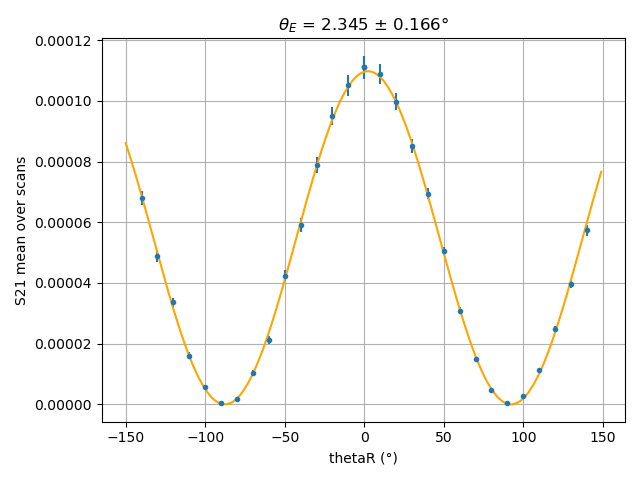

In [89]:
### Avec barres d'erreur
print("Fitting with error bars...")
t = 0 # trace index (S21 or S12)
tt = np.arange(-150, 150, 1)

signal = np.mean(mag_lin[:, 0, :], axis=1)
sigma = interp_func(fold_angles_180(thetaR)) / np.sqrt(nfreqs) # Erreur sur la moyenne en fonction de thetaR
#print(sigma)

# Fit the data
popt, pcov = curve_fit(cos2, thetaR, signal, sigma=sigma, absolute_sigma=True)
error = np.sqrt(np.diag(pcov))

print("Paramètres optimisés :", popt)
print("Erreurs sur les paramètres :", error)

# Residus et chi2
residuals = signal - cos2(thetaR, *popt)

std_res = np.std(residuals)
print("Écart-type des résidus :", std_res)

chi2 = get_chi2(signal, cos2(thetaR, *popt), sigma)
print("Chi2 :", chi2)
chi2_red = chi2 / (len(thetaR) - len(popt))
print("Chi2 réduit :", chi2_red)

fig = plt.figure()
plt.errorbar(thetaR, signal, yerr=sigma, marker='.', ls='None')
plt.plot(tt, cos2(tt, *popt), 'orange', label='Fit cos^2')
plt.xlabel("thetaR (°)")
plt.ylabel("S21 mean over scans")
plt.title(r'$\theta_E$ = {:.3f} ± {:.3f}°'.format(popt[0], error[0]))
plt.grid(10)

plt.tight_layout()

### Ajustement par fréquence

Fitting without error bars
Paramètres optimisés : [4.48101607e-01 1.14029944e-04]
Erreurs sur les paramètres : [6.96678951e-01 1.82266139e-06]
Écart-type des résidus : 5.203864885778562e-06
Chi2 : 30.68957127340754
Chi2 réduit : 1.0960561169074121
Paramètres optimisés : [3.60232734e+00 9.71168106e-05]
Erreurs sur les paramètres : [9.67793171e-01 2.15298671e-06]
Écart-type des résidus : 6.060336172346602e-06
Chi2 : 31.621158092002318
Chi2 réduit : 1.1293270747143684
Paramètres optimisés : [3.31160949e+00 8.07041736e-05]
Erreurs sur les paramètres : [6.24670248e-01 1.15509895e-06]
Écart-type des résidus : 3.3193580712208507e-06
Chi2 : 30.33299943844688
Chi2 réduit : 1.08332140851596
Paramètres optimisés : [3.10949011e+00 9.65950488e-05]
Erreurs sur les paramètres : [5.59653387e-01 1.23884352e-06]
Écart-type des résidus : 3.5786135484393885e-06
Chi2 : 30.01384685565974
Chi2 réduit : 1.071923101987848
Paramètres optimisés : [3.25773043e+00 7.44836153e-05]
Erreurs sur les paramètres : [4.81

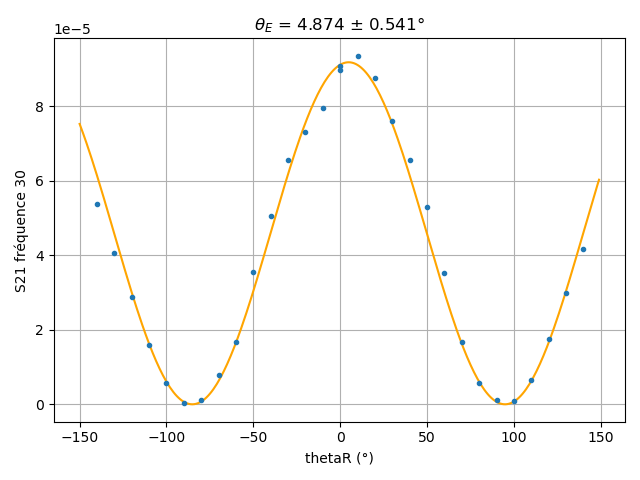

In [90]:
#### Sans donner d'erreur à curve_fit, mais en calculant le chi2 avec les erreurs estimées à partir du STD des résidus
print("Fitting without error bars")
# Loop over frequencies
t = 0 # trace index (S21 or S12)

allthetaE = []
allthetaE_err = []

for f in range(60):
    signal = mag_lin[:, 0, f]

    # Fit the data
    popt, pcov = curve_fit(cos2, thetaR, signal)
    error = np.sqrt(np.diag(pcov))

    print("Paramètres optimisés :", popt)
    allthetaE.append(popt[0])
    print("Erreurs sur les paramètres :", error)
    allthetaE_err.append(error[0])

    # Residus et chi2
    residuals = signal - cos2(thetaR, *popt)
    std_res = np.std(residuals)
    print("Écart-type des résidus :", std_res)
    chi2 = get_chi2(signal, cos2(thetaR, *popt), std_res)
    print("Chi2 :", chi2)

    chi2_red = chi2 / (len(thetaR) - len(popt))
    print("Chi2 réduit :", chi2_red)

    if f == 30:
        fig = plt.figure()
        plt.errorbar(thetaR, signal, yerr=None, marker='.', ls='None')
        plt.plot(tt, cos2(tt, *popt), 'orange', label='Fit cos^2')
        plt.xlabel("thetaR (°)")
        plt.ylabel(f"S21 fréquence {f}")
        plt.title(r'$\theta_E$ = {:.3f} ± {:.3f}°'.format(popt[0], error[0]))
        plt.grid(10)
        fig.tight_layout()

ThetaE moyen : 2.4594871218934626
Écart-type de thetaE : 0.23467853185320706
Erreur sur thetaE 0.07474377199539971


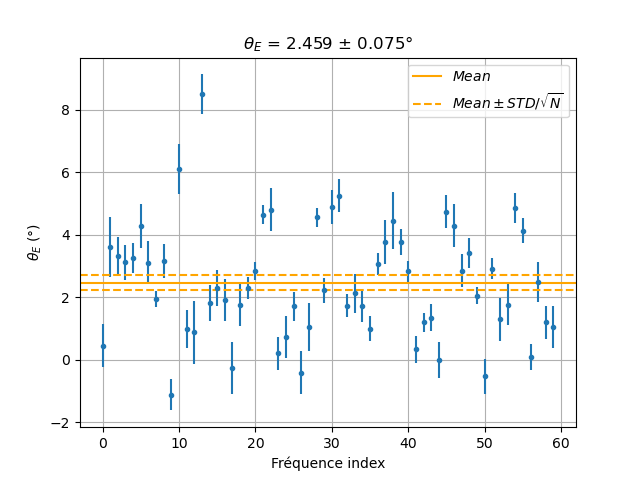

In [92]:
allthetaE = np.array(allthetaE)
allthetaE_err = np.array(allthetaE_err)

mthetaE = np.mean(allthetaE)
print("ThetaE moyen :", mthetaE)
stdthetaE = np.std(allthetaE) / np.sqrt(nfreqs)
print("Écart-type de thetaE :", stdthetaE)

# Erreur sur la moyenne de thetaE
erreur = np.sqrt(np.sum(allthetaE_err**2 )) / nfreqs
print('Erreur sur thetaE', erreur)

fig = plt.figure()
plt.errorbar(np.arange(len(allthetaE)), allthetaE, yerr=allthetaE_err, fmt='.')
plt.axhline(mthetaE, color='orange', label=r'$Mean$')
plt.axhline(mthetaE-stdthetaE, color='orange', ls='--')
plt.axhline(mthetaE+stdthetaE, color='orange', label=r'$Mean \pm STD/\sqrt{N}$', ls='--')
plt.xlabel("Fréquence index")
plt.ylabel(r'$\theta_E$ (°)')
plt.title(r'$\theta_E$ = {:.3f} ± {:.3f}°'.format(mthetaE, erreur))
plt.grid(10)
plt.legend()
fig.savefig(f"../Plots/Malus_Fit_avec_sigma1e-6_allthetaE", dpi=300)

Fitting with error bars
All chi2 reduits [0.1615128  0.15941709 0.06623313 0.10782015 0.03466751 0.08012222
 0.10072212 0.04112754 0.10999103 0.07712157 0.14735734 0.15150515
 0.2153792  0.0940869  0.12455767 0.05368866 0.11183292 0.1017155
 0.09768555 0.06106776 0.03222161 0.06520372 0.29264267 0.09644357
 0.08138471 0.05605454 0.16547017 0.06971327 0.06463996 0.06122112
 0.07008103 0.07289641 0.04476284 0.08569062 0.07241449 0.03871697
 0.05055783 0.10631722 0.13141244 0.10471665 0.06402761 0.06019697
 0.02958697 0.04134313 0.06445517 0.11708199 0.17241848 0.08690368
 0.06220674 0.04076085 0.06330792 0.05005516 0.12317212 0.12415932
 0.14136181 0.08595679 0.09332287 0.19190117 0.07402451 0.14136515]
ThetaE moyen : 2.3364543101411446
Écart-type de thetaE : 1.3316221665401606
Erreur sur thetaE 0.17126900405971135


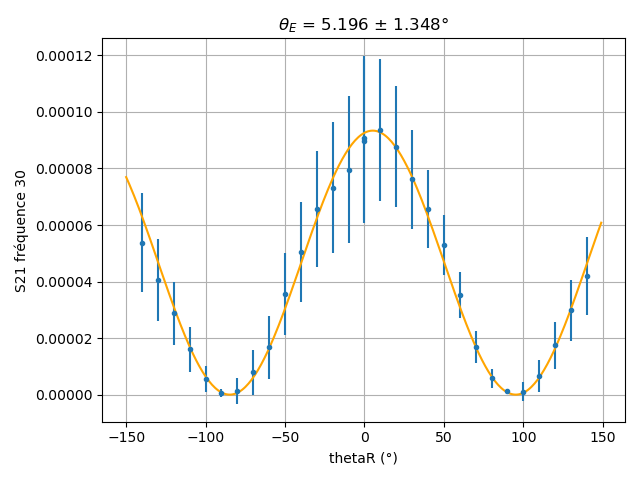

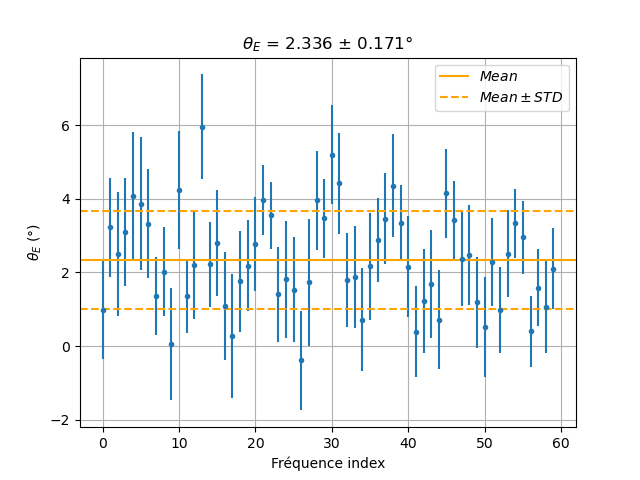

In [104]:
#### Sans with error bars
print("Fitting with error bars")
# Loop over frequencies
t = 0 # trace index (S21 or S12)

allthetaE = []
allthetaE_err = []
allchi2_red = []

for f in range(60):
    signal = mag_lin[:, 0, f]
    sigma = interp_func(fold_angles_180(thetaR))

    # Fit the data
    popt, pcov = curve_fit(cos2, thetaR, signal, sigma=sigma, absolute_sigma=True)
    error = np.sqrt(np.diag(pcov))

    #print("Paramètres optimisés :", popt)
    allthetaE.append(popt[0])
    #print("Erreurs sur les paramètres :", error)
    allthetaE_err.append(error[0])

    # Chi2
    chi2 = get_chi2(signal, cos2(thetaR, *popt), sigma)

    chi2_red = chi2 / (len(thetaR) - len(popt))
    allchi2_red.append(chi2_red)

    if f == 30:
        fig = plt.figure()
        plt.errorbar(thetaR, signal, yerr=sigma, marker='.', ls='None')
        plt.plot(tt, cos2(tt, *popt), 'orange', label='Fit cos^2')
        plt.xlabel("thetaR (°)")
        plt.ylabel(f"S21 fréquence {f}")
        plt.title(r'$\theta_E$ = {:.3f} ± {:.3f}°'.format(popt[0], error[0]))
        plt.grid(10)
        fig.tight_layout()


allthetaE = np.array(allthetaE)
allthetaE_err = np.array(allthetaE_err)
allchi2_red = np.array(allchi2_red)

print("All chi2 reduits", allchi2_red)

mthetaE = np.mean(allthetaE)
print("ThetaE moyen :", mthetaE)
stdthetaE = np.std(allthetaE) #/ np.sqrt(nfreqs)
print("Écart-type de thetaE :", stdthetaE)

# Erreur sur la moyenne de thetaE
erreur = np.sqrt(np.sum(allthetaE_err**2 )) / nfreqs
print('Erreur sur thetaE', erreur)

fig = plt.figure()
plt.errorbar(np.arange(len(allthetaE)), allthetaE, yerr=allthetaE_err, fmt='.')
plt.axhline(mthetaE, color='orange', label=r'$Mean$')
plt.axhline(mthetaE-stdthetaE, color='orange', ls='--')
plt.axhline(mthetaE+stdthetaE, color='orange', label=r'$Mean \pm STD$', ls='--')
plt.xlabel("Fréquence index")
plt.ylabel(r'$\theta_E$ (°)')
plt.title(r'$\theta_E$ = {:.3f} ± {:.3f}°'.format(mthetaE, erreur))
plt.grid(10)
plt.legend()
fig.savefig(f"../Plots/Malus_Fit_avec_sigma1e-6_allthetaE", dpi=300)